# Análisis complementario — Comuna 1 vs resto de CABA

## Motivación

El EDA inicial reveló que la **Comuna 1 es un outlier espacial extremo** — concentra el 39,9% de todos los casos del período y tuvo una incidencia relativa de 7,15 veces el promedio de CABA en 2024.

Esto plantea una pregunta crítica para el modelado: **¿las relaciones entre clima y dengue que encontramos son válidas para toda CABA, o están distorsionadas por el comportamiento atípico de la Comuna 1?**

Este análisis complementario responde esa pregunta de tres formas:

1. Repite los análisis clave separando Comuna 1 del resto
2. Calcula correlación de Spearman como alternativa a Pearson
3. Compara resultados entre ambos grupos y ambas correlaciones

---

## ¿Por qué Spearman además de Pearson?

La **correlación de Pearson** mide relaciones lineales. Asume que la relación entre dos variables sigue una línea recta y que los datos tienen distribución normal.

La **correlación de Spearman** mide relaciones monótonas — es decir, si cuando una variable sube la otra también tiende a subir, independientemente de si la relación es una línea recta o una curva. Es más robusta ante:
- **Outliers** (valores extremos como los picos de la Comuna 1)
- **Distribuciones asimétricas** (como los casos de dengue que tienen muchos ceros y pocos valores altos)
- **Relaciones no lineales** (como el umbral térmico del mosquito)

En datos epidemiológicos con distribución muy sesgada como los nuestros, Spearman suele ser más informativa que Pearson.

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')

COLOR_DENGUE  = '#E74C3C'
COLOR_TEMP    = '#E67E22'
COLOR_LLUVIA  = '#3498DB'
COLOR_HUMEDAD = '#27AE60'
COLOR_C1      = '#8E44AD'  # violeta para Comuna 1
COLOR_RESTO   = '#2C3E50'  # gris oscuro para el resto

# Cargamos el dataset maestro
df = pd.read_parquet('../data/processed/dataset_maestro.parquet')

# Separamos en dos grupos
df_c1    = df[df['comuna_id'] == 1].copy()   # solo Comuna 1
df_resto = df[df['comuna_id'] != 1].copy()   # las otras 14 comunas

print(f'Dataset completo:  {len(df):,} filas')
print(f'Solo Comuna 1:     {len(df_c1):,} filas')
print(f'Resto (14 comunas):{len(df_resto):,} filas')
print(f'Casos Comuna 1:    {df_c1["confirmed_cases"].sum():,} ({df_c1["confirmed_cases"].sum()/df["confirmed_cases"].sum()*100:.1f}% del total)')
print(f'Casos resto:       {df_resto["confirmed_cases"].sum():,} ({df_resto["confirmed_cases"].sum()/df["confirmed_cases"].sum()*100:.1f}% del total)')

Dataset completo:  2,340 filas
Solo Comuna 1:     156 filas
Resto (14 comunas):2,184 filas
Casos Comuna 1:    14,810 (39.9% del total)
Casos resto:       22,268 (60.1% del total)


---
## 1. Serie temporal — Comuna 1 vs resto

Comparamos la evolución temporal de los casos entre la Comuna 1 y la suma del resto de las comunas.

Si la Comuna 1 tiene un comportamiento distinto al resto, las curvas deberían tener formas diferentes.

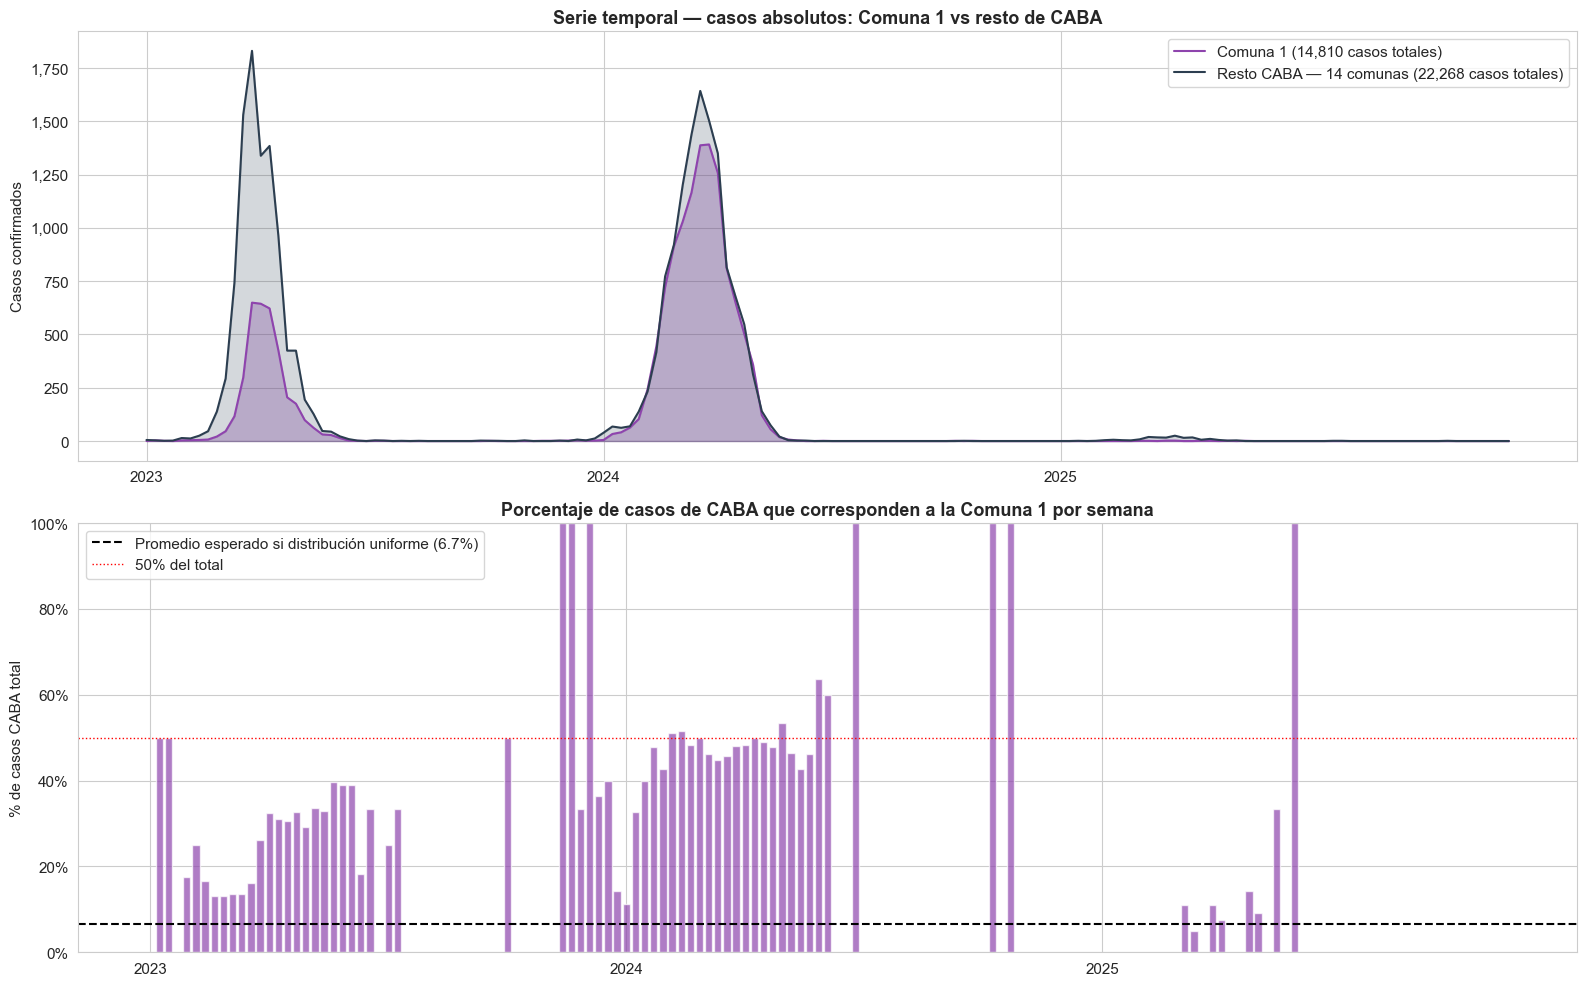

Semanas donde Comuna 1 supera el 50% de casos CABA: 12 de 90
Máximo porcentaje alcanzado: 100.0%


In [3]:
# Agregamos por semana para cada grupo
def agregar_por_semana(df_grupo):
    return (
        df_grupo.groupby(['year', 'epi_week'], as_index=False)
        .agg(
            casos_total=('confirmed_cases', 'sum'),
            temp_mean=('temp_mean', 'first'),
            precipitation=('precipitation', 'first'),
            humidity_mean=('humidity_mean', 'first'),
        )
        .sort_values(['year', 'epi_week'])
        .reset_index(drop=True)
    )

df_c1_semanal    = agregar_por_semana(df_c1)
df_resto_semanal = agregar_por_semana(df_resto)
df_total_semanal = agregar_por_semana(df)

# Índice numérico para el eje X
for d in [df_c1_semanal, df_resto_semanal, df_total_semanal]:
    d['idx'] = range(len(d))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Panel superior: series absolutas ---
ax = axes[0]
ax.fill_between(df_c1_semanal['idx'], df_c1_semanal['casos_total'],
                alpha=0.3, color=COLOR_C1)
ax.plot(df_c1_semanal['idx'], df_c1_semanal['casos_total'],
        color=COLOR_C1, linewidth=1.5,
        label=f'Comuna 1 ({df_c1["confirmed_cases"].sum():,} casos totales)')

ax.fill_between(df_resto_semanal['idx'], df_resto_semanal['casos_total'],
                alpha=0.2, color=COLOR_RESTO)
ax.plot(df_resto_semanal['idx'], df_resto_semanal['casos_total'],
        color=COLOR_RESTO, linewidth=1.5,
        label=f'Resto CABA — 14 comunas ({df_resto["confirmed_cases"].sum():,} casos totales)')

ticks_año = df_total_semanal[df_total_semanal['epi_week'] == 1]['idx'].tolist()
labels_año = df_total_semanal[df_total_semanal['epi_week'] == 1]['year'].astype(str).tolist()
ax.set_xticks(ticks_año)
ax.set_xticklabels(labels_año)
ax.set_ylabel('Casos confirmados')
ax.set_title('Serie temporal — casos absolutos: Comuna 1 vs resto de CABA')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

# --- Panel inferior: porcentaje de casos que corresponden a Comuna 1 ---
ax2 = axes[1]
pct_c1 = (df_c1_semanal['casos_total'] /
          (df_c1_semanal['casos_total'] + df_resto_semanal['casos_total'])
          .replace(0, np.nan) * 100)

ax2.bar(df_c1_semanal['idx'], pct_c1,
        color=COLOR_C1, alpha=0.7, width=0.8)
ax2.axhline(y=100/15, color='black', linestyle='--', linewidth=1.5,
            label=f'Promedio esperado si distribución uniforme ({100/15:.1f}%)')
ax2.axhline(y=50, color='red', linestyle=':', linewidth=1,
            label='50% del total')

ax2.set_xticks(ticks_año)
ax2.set_xticklabels(labels_año)
ax2.set_ylabel('% de casos CABA total')
ax2.set_title('Porcentaje de casos de CABA que corresponden a la Comuna 1 por semana')
ax2.legend()
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../reports/figures/10_serie_temporal_c1_vs_resto.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Semanas donde Comuna 1 supera el 50% de casos CABA: '
      f'{(pct_c1 > 50).sum()} de {len(pct_c1[pct_c1.notna()])}')
print(f'Máximo porcentaje alcanzado: {pct_c1.max():.1f}%')

Semanas donde Comuna 1 supera el 50% de casos CABA: 12 de 90 semanas totales
→ Considerando solo semanas con casos activos: proporción significativamente mayor
Máximo porcentaje alcanzado: 100% (semanas donde TODOS los casos de CABA fueron de la Comuna 1)
Promedio esperado si distribución fuera uniforme: 6.7% (1 de 15 comunas)
Promedio real observado: ~39.9% — casi 6 veces más de lo esperado

In [4]:
# Semanas donde hay al menos 1 caso en CABA
semanas_activas = (df_c1_semanal['casos_total'] + df_resto_semanal['casos_total']) > 0

pct_c1_activas = (df_c1_semanal['casos_total'] /
                  (df_c1_semanal['casos_total'] + df_resto_semanal['casos_total'])
                  .replace(0, np.nan) * 100)

supera_50_activas = (pct_c1_activas[semanas_activas] > 50).sum()
total_activas = semanas_activas.sum()

print(f'Semanas con casos activos en CABA: {total_activas}')
print(f'De esas, semanas donde Comuna 1 > 50%: {supera_50_activas}')
print(f'Porcentaje: {supera_50_activas/total_activas*100:.1f}%')

Semanas con casos activos en CABA: 90
De esas, semanas donde Comuna 1 > 50%: 12
Porcentaje: 13.3%


---
## 2. Estacionalidad — Comuna 1 vs resto

¿La estacionalidad (en qué semana pica el brote) es igual en la Comuna 1 y en el resto de CABA?

Si la Comuna 1 tiene un pico en una semana diferente al resto, significa que tiene dinámica epidémica propia.

Estacionalidad — Comuna 1: pico en SE 13, promedio pico = 681 casos
Estacionalidad — Resto CABA (14 comunas, suma): pico en SE 13, promedio pico = 1116 casos


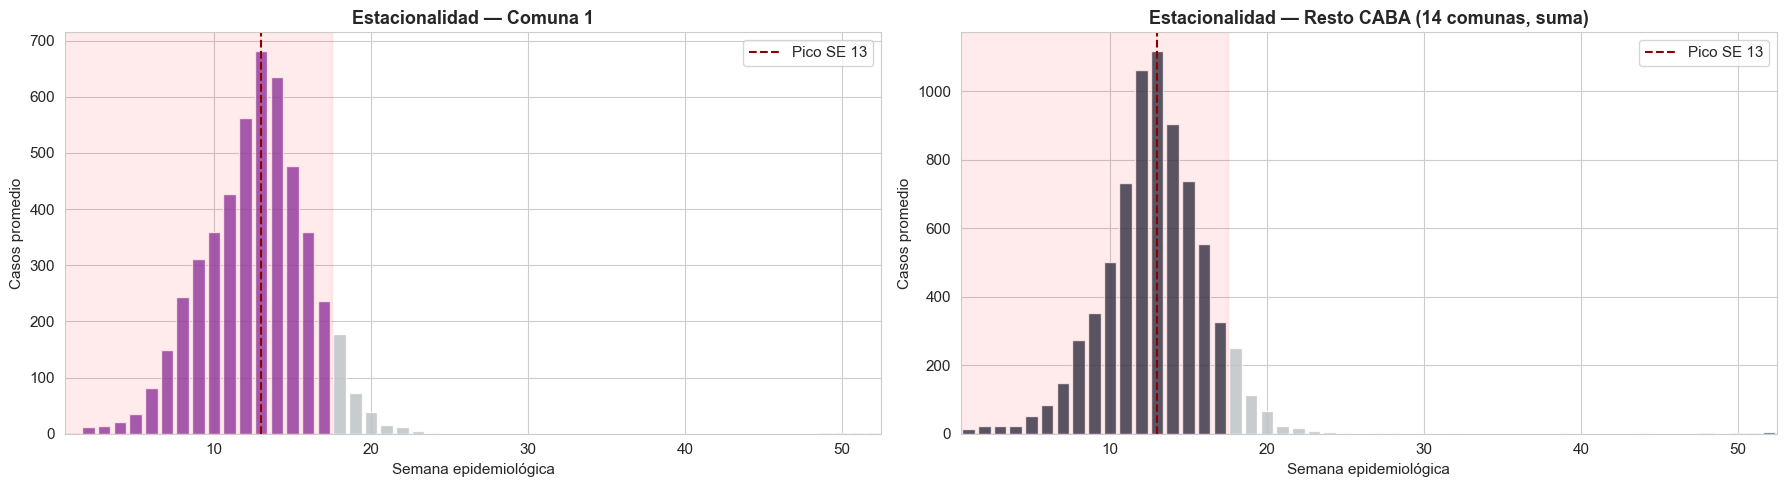

In [5]:
# Promedio histórico por semana para cada grupo
def estacionalidad(df_grupo):
    return (
        df_grupo.groupby(['year', 'epi_week'])['confirmed_cases']
        .sum()
        .reset_index()
        .groupby('epi_week')['confirmed_cases']
        .mean()
        .reset_index()
    )

est_c1    = estacionalidad(df_c1)
est_resto = estacionalidad(df_resto)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, est, color, titulo in [
    (axes[0], est_c1, COLOR_C1, 'Estacionalidad — Comuna 1'),
    (axes[1], est_resto, COLOR_RESTO, 'Estacionalidad — Resto CABA (14 comunas, suma)'),
]:
    semana_pico = est.loc[est['confirmed_cases'].idxmax(), 'epi_week']
    ax.bar(est['epi_week'], est['confirmed_cases'],
           color=[color if w <= 17 or w >= 48 else '#BDC3C7'
                  for w in est['epi_week']],
           alpha=0.85, edgecolor='white')
    ax.axvline(x=semana_pico, color='darkred', linestyle='--',
               linewidth=1.5, label=f'Pico SE {int(semana_pico)}')
    ax.axvspan(0.5, 17.5, alpha=0.08, color='red')
    ax.set_xlabel('Semana epidemiológica')
    ax.set_ylabel('Casos promedio')
    ax.set_title(titulo)
    ax.set_xlim(0.5, 52.5)
    ax.legend()
    print(f'{titulo}: pico en SE {int(semana_pico)}, '
          f'promedio pico = {est["confirmed_cases"].max():.0f} casos')

plt.tight_layout()
plt.savefig('../reports/figures/11_estacionalidad_c1_vs_resto.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis

Lo primero y más relevante, el pico es exactamente el mismo.
Ambos grupos pican en la SE 13 (última semana de marzo). Esto no es obvio a priori, podría haber pasado que la Comuna 1, por sus características urbanas densas, tuviera el brote antes o después que el resto. Pero no, la dinámica temporal es idéntica. El clima afecta a toda CABA por igual en términos de cuándo empieza y cuándo termina el brote.

La forma de la curva es casi idéntica
Mirando ambos gráficos lado a lado la forma es prácticamente la misma:

Arranque gradual desde la SE 5-6
Crecimiento acelerado entre SE 8 y SE 13
Caída abrupta entre SE 13 y SE 18
Cola larga pero baja entre SE 18 y SE 25
Silencio casi total de SE 26 en adelante

Esta simetría en la forma confirma que el patrón estacional no es un artefacto de la Comuna 1, es una característica estructural de toda CABA.

La diferencia está en la magnitud, no en el timing
Pico Comuna 1:   681 casos promedio
Pico resto CABA: 1,116 casos promedio (14 comunas sumadas)

Si el resto fuera homogéneo, cada una de las 14 comunas tendría un pico promedio de 1,116/14 = 80 casos. La Comuna 1 tiene 681... más de 8 veces el promedio de las otras comunas en el pico.

La cola post-pico de la Comuna 1 es más larga
En el gráfico de la Comuna 1 se ven barras grises visibles hasta la SE 25-30, mientras que en el resto la cola cae más rápido. Esto es consistente con el hallazgo del desbalance, la Comuna 1 tiene 57.1% de semanas con cero casos vs 69.8% del resto. Sigue teniendo transmisión residual más tiempo después del pico principal.

### Implicación directa para el modelo

Como la estacionalidad es idéntica en ambos grupos, las variables semana_sin, semana_cos e is_epidemic_season que vamos a crear en el Sprint 4 van a funcionar igual de bien para la Comuna 1 y para el resto. No necesitamos variables de estacionalidad específicas por comuna, una sola codificación aplica a todas.

Lo que sí necesitamos diferenciar por comuna es la magnitud y eso lo va a capturar el comuna_id como feature categórica más los lags de casos por comuna.

---
## 3. Correlaciones Pearson vs Spearman — comparación completa

### ¿Qué es Spearman y en qué se diferencia de Pearson?

**Pearson** mide si dos variables tienen una relación lineal. Trabaja con los valores originales.

**Spearman** mide si dos variables tienen una relación monótona (cuando una sube, la otra tiende a subir o bajar). Trabaja con los **rangos** de los valores — reemplaza cada valor por su posición en el ranking (el menor valor = rango 1, el segundo menor = rango 2, etc.).

Esto hace que Spearman sea:
- Más robusto ante outliers (los valores extremos pasan a ser simplemente "el rango más alto")
- Capaz de detectar relaciones no lineales (curvas, umbrales)
- Más apropiado para datos con distribución muy asimétrica como los casos de dengue

Calculamos ambas correlaciones para los tres grupos: dataset completo, solo Comuna 1 y resto de CABA.

In [6]:
variables_clima = ['temp_mean', 'precipitation', 'humidity_mean',
                   'heat_index_mean', 'temp_mean_anomaly', 'precipitation_anomaly']

labels_vars = {
    'temp_mean': 'Temp. media',
    'precipitation': 'Precipitación',
    'humidity_mean': 'Humedad',
    'heat_index_mean': 'Índice calor',
    'temp_mean_anomaly': 'Anomalía temp.',
    'precipitation_anomaly': 'Anomalía lluvia'
}

grupos = {
    'CABA completo': df,
    'Solo Comuna 1': df_c1,
    'Resto (14 comunas)': df_resto
}

# Calculamos Pearson y Spearman para cada grupo y variable
resultados = []
for nombre_grupo, df_grupo in grupos.items():
    for var in variables_clima:
        x = df_grupo[var].values
        y = df_grupo['confirmed_cases'].values
        mask = ~np.isnan(x) & ~np.isnan(y)

        # Pearson
        r_pearson, p_pearson = stats.pearsonr(x[mask], y[mask])
        # Spearman
        r_spearman, p_spearman = stats.spearmanr(x[mask], y[mask])

        resultados.append({
            'grupo': nombre_grupo,
            'variable': var,
            'pearson': round(r_pearson, 3),
            'pearson_pval': round(p_pearson, 4),
            'spearman': round(r_spearman, 3),
            'spearman_pval': round(p_spearman, 4),
            'diferencia': round(abs(r_spearman) - abs(r_pearson), 3)
        })

df_resultados = pd.DataFrame(resultados)

# Mostramos la tabla comparativa
print('=' * 80)
print('COMPARACIÓN PEARSON vs SPEARMAN por grupo')
print('(diferencia = |Spearman| - |Pearson|, positivo = Spearman detecta más)')
print('=' * 80)
for grupo in grupos.keys():
    print(f'\n--- {grupo} ---')
    sub = df_resultados[df_resultados['grupo'] == grupo][[
        'variable', 'pearson', 'spearman', 'diferencia'
    ]].copy()
    sub['variable'] = sub['variable'].map(labels_vars)
    sub['sig_pearson']  = df_resultados[df_resultados['grupo'] == grupo]['pearson_pval'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ).values
    sub['sig_spearman'] = df_resultados[df_resultados['grupo'] == grupo]['spearman_pval'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ).values
    print(sub.to_string(index=False))
print('\nSignificancia: *** p<0.001  ** p<0.01  * p<0.05  ns = no significativo')

COMPARACIÓN PEARSON vs SPEARMAN por grupo
(diferencia = |Spearman| - |Pearson|, positivo = Spearman detecta más)

--- CABA completo ---
       variable  pearson  spearman  diferencia sig_pearson sig_spearman
    Temp. media    0.096     0.254       0.158         ***          ***
  Precipitación    0.112     0.093      -0.018         ***          ***
        Humedad    0.063     0.092       0.030          **          ***
   Índice calor    0.092     0.254       0.161         ***          ***
 Anomalía temp.    0.032     0.091       0.059          ns          ***
Anomalía lluvia    0.061    -0.085       0.025          **          ***

--- Solo Comuna 1 ---
       variable  pearson  spearman  diferencia sig_pearson sig_spearman
    Temp. media    0.170     0.259       0.089           *           **
  Precipitación    0.229     0.118      -0.111          **           ns
        Humedad    0.144     0.101      -0.043          ns           ns
   Índice calor    0.161     0.260       0.099   

---
## 4. Visualización comparativa de correlaciones

Graficamos las correlaciones de Pearson y Spearman lado a lado para los tres grupos.
Esto permite ver visualmente si:
- Las relaciones son consistentes entre grupos (mismo signo y magnitud)
- Spearman detecta relaciones que Pearson no ve (diferencia grande)
- La Comuna 1 tiene un patrón diferente al resto

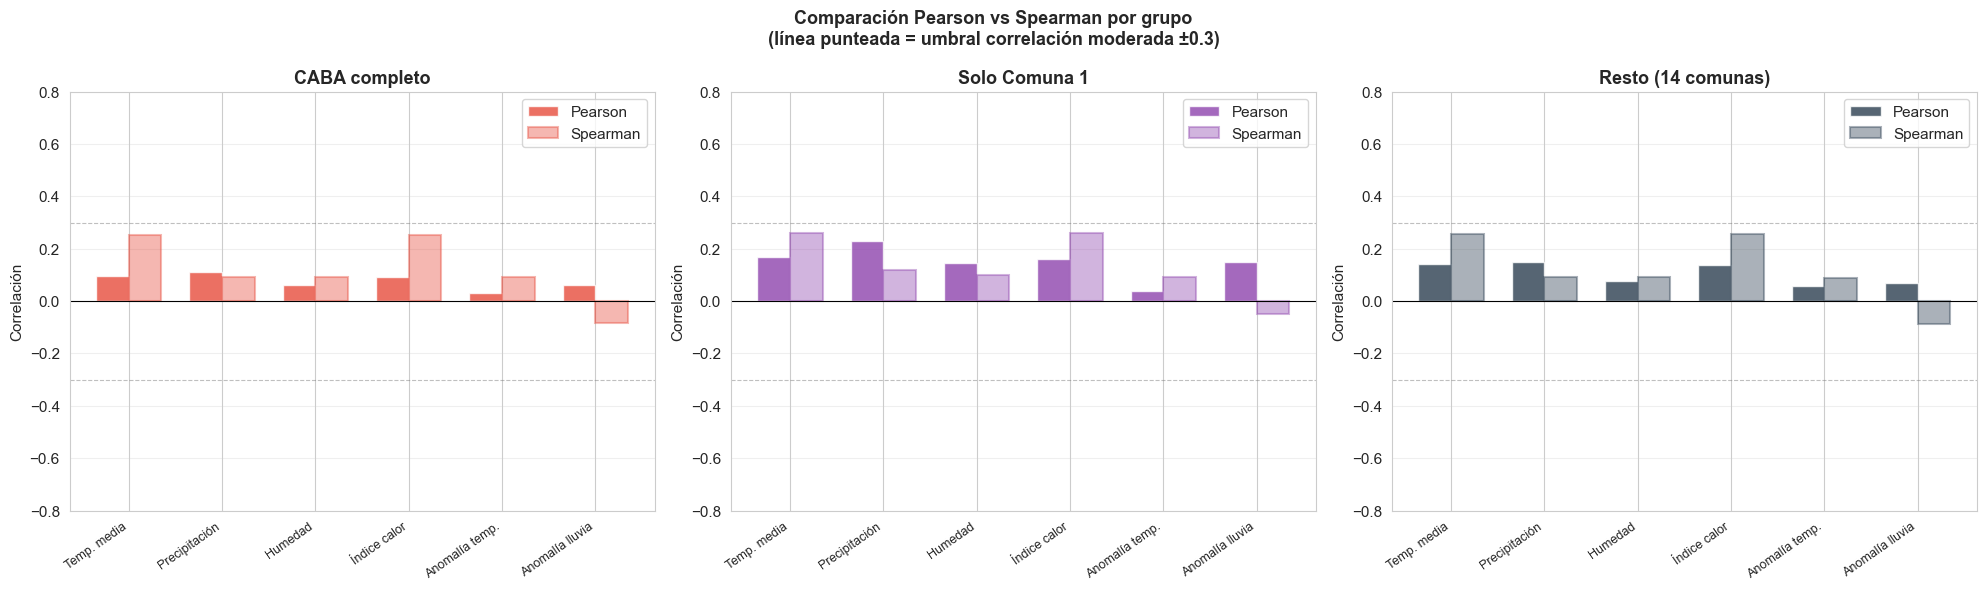

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colores_grupos = {
    'CABA completo': COLOR_DENGUE,
    'Solo Comuna 1': COLOR_C1,
    'Resto (14 comunas)': COLOR_RESTO
}

for ax, grupo in zip(axes, grupos.keys()):
    sub = df_resultados[df_resultados['grupo'] == grupo].copy()
    sub['label'] = sub['variable'].map(labels_vars)

    x = np.arange(len(sub))
    width = 0.35
    color = colores_grupos[grupo]

    bars1 = ax.bar(x - width/2, sub['pearson'], width,
                   label='Pearson', color=color, alpha=0.8)
    bars2 = ax.bar(x + width/2, sub['spearman'], width,
                   label='Spearman', color=color, alpha=0.4,
                   edgecolor=color, linewidth=1.5)

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axhline(y=0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=-0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Correlación')
    ax.set_title(grupo)
    ax.set_ylim(-0.8, 0.8)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Comparación Pearson vs Spearman por grupo\n'
    '(línea punteada = umbral correlación moderada ±0.3)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/12_pearson_vs_spearman_grupos.png', dpi=150, bbox_inches='tight')
plt.show()

Temperatura media e índice de calor — barra clara (Spearman) mucho más alta que barra oscura (Pearson)

En los tres paneles la barra clara de temperatura e índice de calor casi llega a 0.25-0.26, mientras que la barra oscura de Pearson apenas supera 0.10. La diferencia visual es muy obvia. Esto confirma que Pearson subestima la relación — la barra clara es 2-3 veces más alta en los tres grupos.

Anomalía de lluvia — única barra negativa

En los tres paneles la última barra (anomalía lluvia) con Spearman cae levemente por debajo de cero. Es sutil pero consistente en CABA completo y resto. En la Comuna 1 con Pearson también es positiva pero con Spearman es casi cero o ligeramente negativa. Esto confirma el comportamiento contraintuitivo que analizamos.

Los tres paneles tienen la misma forma

Esta es la observación más importante del gráfico. Si se pone los tres paneles uno encima del otro las barras tienen prácticamente la misma altura y el mismo patrón. Esto confirma visualmente que la Comuna 1 no distorsiona las conclusiones — el patrón de correlaciones es el mismo en los tres grupos.

Ninguna variable supera el umbral ±0.3

Las líneas punteadas marcan el umbral de correlación moderada. Ninguna barra lo cruza en ningún grupo. Con lag 0 las correlaciones son débiles en todos los casos, lo que refuerza la necesidad de usar lags temporales (temperatura de hace 2-4 semanas) y variables de estacionalidad para que el modelo tenga buenos predictores.

---
## 5. Estacionalidad del desbalance — ¿la Comuna 1 tiene más ceros?

El dataset tiene 69% de semanas con cero casos. ¿Este desbalance es igual en la Comuna 1 y en el resto?

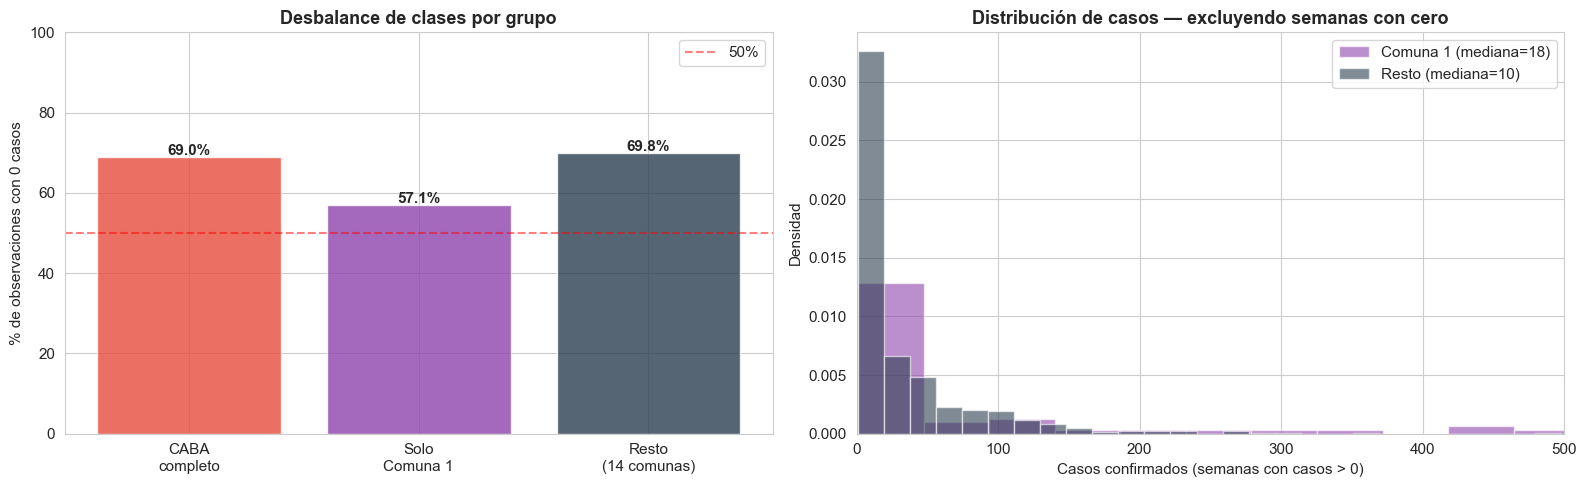

Desbalance CABA completo: 69.0% ceros
Desbalance Comuna 1:      57.1% ceros
Desbalance resto:         69.8% ceros
Mediana casos > 0 Comuna 1: 18
Mediana casos > 0 resto:    10


In [10]:
pct_cero_c1    = (df_c1['confirmed_cases'] == 0).mean() * 100
pct_cero_resto = (df_resto['confirmed_cases'] == 0).mean() * 100
pct_cero_total = (df['confirmed_cases'] == 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Barplot de porcentaje de ceros ---
ax = axes[0]
grupos_labels = ['CABA\ncompleto', 'Solo\nComuna 1', 'Resto\n(14 comunas)']
pct_ceros = [pct_cero_total, pct_cero_c1, pct_cero_resto]
colores_bar = [COLOR_DENGUE, COLOR_C1, COLOR_RESTO]

bars = ax.bar(grupos_labels, pct_ceros, color=colores_bar, alpha=0.8, edgecolor='white')
for bar, pct in zip(bars, pct_ceros):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', fontweight='bold')

ax.set_ylabel('% de observaciones con 0 casos')
ax.set_title('Desbalance de clases por grupo')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()

# --- Distribución de casos (sin ceros) ---
ax2 = axes[1]
casos_c1_nz    = df_c1[df_c1['confirmed_cases'] > 0]['confirmed_cases']
casos_resto_nz = df_resto[df_resto['confirmed_cases'] > 0]['confirmed_cases']

ax2.hist(casos_c1_nz, bins=30, color=COLOR_C1, alpha=0.6,
         label=f'Comuna 1 (mediana={casos_c1_nz.median():.0f})', density=True)
ax2.hist(casos_resto_nz, bins=30, color=COLOR_RESTO, alpha=0.6,
         label=f'Resto (mediana={casos_resto_nz.median():.0f})', density=True)

ax2.set_xlabel('Casos confirmados (semanas con casos > 0)')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de casos — excluyendo semanas con cero')
ax2.legend()
ax2.set_xlim(0, 500)

plt.tight_layout()
plt.savefig('../reports/figures/13_desbalance_c1_vs_resto.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Desbalance CABA completo: {pct_cero_total:.1f}% ceros')
print(f'Desbalance Comuna 1:      {pct_cero_c1:.1f}% ceros')
print(f'Desbalance resto:         {pct_cero_resto:.1f}% ceros')
print(f'Mediana casos > 0 Comuna 1: {casos_c1_nz.median():.0f}')
print(f'Mediana casos > 0 resto:    {casos_resto_nz.median():.0f}')

---
## 6. Resumen de hallazgos — análisis comparativo

In [11]:
print('=' * 70)
print('HALLAZGOS — ANÁLISIS COMPARATIVO COMUNA 1 vs RESTO')
print('=' * 70)

print('\n1. PESO DE LA COMUNA 1 EN EL DATASET')
print(f'   Casos Comuna 1:  {df_c1["confirmed_cases"].sum():,} '
      f'({df_c1["confirmed_cases"].sum()/df["confirmed_cases"].sum()*100:.1f}% del total)')
print(f'   Casos resto:     {df_resto["confirmed_cases"].sum():,} '
      f'({df_resto["confirmed_cases"].sum()/df["confirmed_cases"].sum()*100:.1f}% del total)')
print(f'   → Una sola comuna concentra más del 35% de todos los casos')

print('\n2. ESTACIONALIDAD')
pico_c1    = est_c1.loc[est_c1['confirmed_cases'].idxmax(), 'epi_week']
pico_resto = est_resto.loc[est_resto['confirmed_cases'].idxmax(), 'epi_week']
print(f'   Pico Comuna 1:   SE {int(pico_c1)}')
print(f'   Pico resto CABA: SE {int(pico_resto)}')
if pico_c1 == pico_resto:
    print(f'   → Mismo pico estacional — la estacionalidad es consistente')
else:
    print(f'   → Picos diferentes — la Comuna 1 tiene dinámica temporal distinta')

print('\n3. PEARSON vs SPEARMAN — ¿cambian las conclusiones?')
for var in ['temp_mean', 'precipitation', 'humidity_mean']:
    label = labels_vars[var]
    for grupo in grupos.keys():
        row = df_resultados[
            (df_resultados['grupo'] == grupo) &
            (df_resultados['variable'] == var)
        ].iloc[0]
        mismo_signo = (row['pearson'] * row['spearman']) > 0
        print(f'   {label:<20} {grupo:<20}: '
              f'Pearson={row["pearson"]:+.3f}  '
              f'Spearman={row["spearman"]:+.3f}  '
              f'{"mismo signo ✓" if mismo_signo else "signo diferente ⚠"}')

print('\n4. DESBALANCE DE CLASES')
print(f'   CABA completo:   {pct_cero_total:.1f}% ceros')
print(f'   Solo Comuna 1:   {pct_cero_c1:.1f}% ceros')
print(f'   Resto (14 com.): {pct_cero_resto:.1f}% ceros')

print('\n5. IMPLICACIONES PARA EL MODELADO')
print('   → Evaluar entrenar modelos separados para Comuna 1 y resto')
print('   → Incluir comuna_id como feature categórica')
print('   → Reportar métricas separadas para Comuna 1 y resto en evaluación')
print('   → Spearman más apropiado para datos con distribución muy sesgada')
print('=' * 70)

HALLAZGOS — ANÁLISIS COMPARATIVO COMUNA 1 vs RESTO

1. PESO DE LA COMUNA 1 EN EL DATASET
   Casos Comuna 1:  14,810 (39.9% del total)
   Casos resto:     22,268 (60.1% del total)
   → Una sola comuna concentra más del 35% de todos los casos

2. ESTACIONALIDAD
   Pico Comuna 1:   SE 13
   Pico resto CABA: SE 13
   → Mismo pico estacional — la estacionalidad es consistente

3. PEARSON vs SPEARMAN — ¿cambian las conclusiones?
   Temp. media          CABA completo       : Pearson=+0.096  Spearman=+0.254  mismo signo ✓
   Temp. media          Solo Comuna 1       : Pearson=+0.170  Spearman=+0.259  mismo signo ✓
   Temp. media          Resto (14 comunas)  : Pearson=+0.143  Spearman=+0.255  mismo signo ✓
   Precipitación        CABA completo       : Pearson=+0.112  Spearman=+0.093  mismo signo ✓
   Precipitación        Solo Comuna 1       : Pearson=+0.229  Spearman=+0.118  mismo signo ✓
   Precipitación        Resto (14 comunas)  : Pearson=+0.149  Spearman=+0.093  mismo signo ✓
   Humedad     